## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000023DBC550740> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2009-2023_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.936785
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.526527
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.321799
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012812
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.438097


In [6]:
timeline_file.shape

(3801732, 33)

In [7]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


In [8]:
wnv_file.shape

(84, 4)

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [11]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [12]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_month'] = temp_df['rainfall'].rolling(window=30, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [13]:
dataset.dtypes

NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
day                            int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
lst_jan_day_mean             float64
lst_feb_day_mean             float64
lst_mar_day_mean             float64
l

In [14]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [15]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [16]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [17]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [18]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

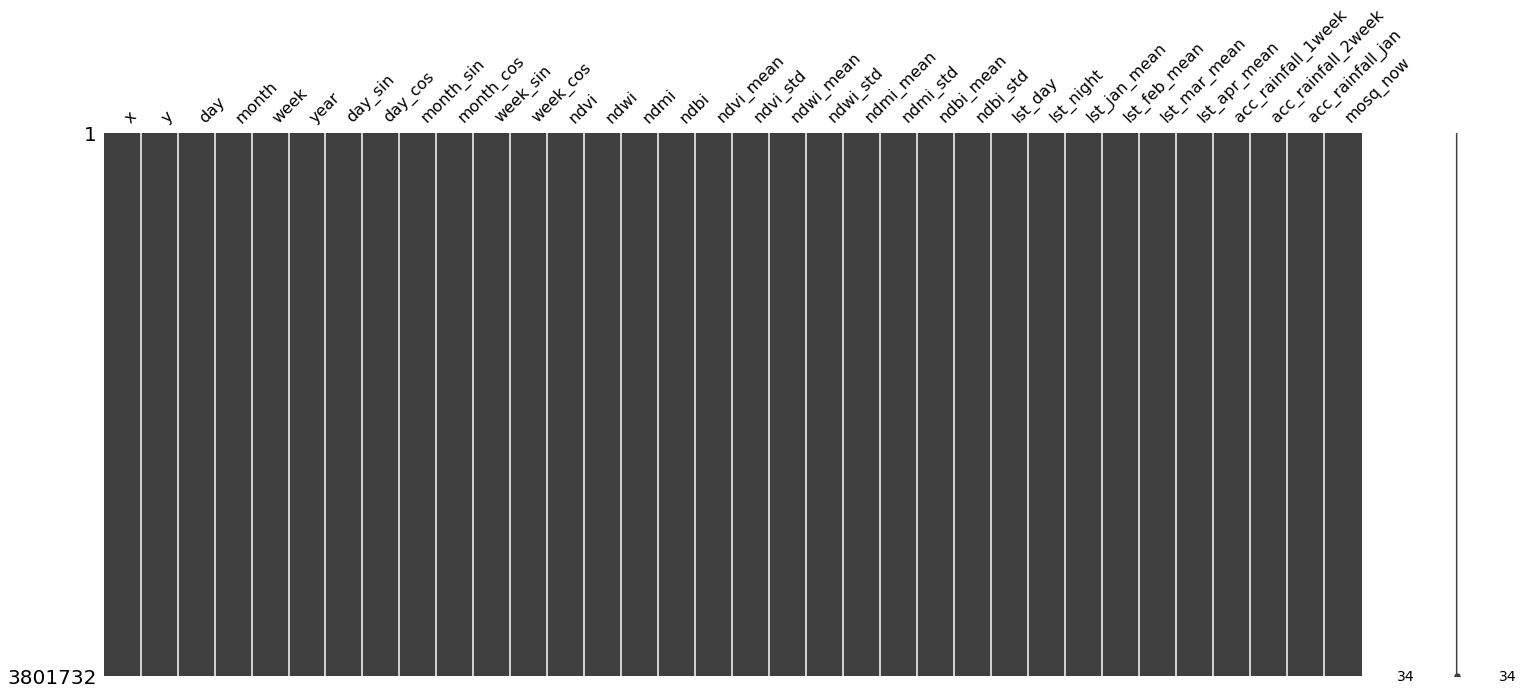

In [19]:
missingno.matrix(dataset_mamoth)

In [20]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [21]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [22]:
predictions = give_predictions(model, dataset_mamoth)

In [23]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.190210,39.655160,2009-01-01,1
1,21.190210,39.655160,2009-01-02,1
2,21.190210,39.655160,2009-01-03,11
3,21.190210,39.655160,2009-01-04,11
4,21.190210,39.655160,2009-01-05,11
...,...,...,...,...
3801727,23.300860,39.203310,2023-12-27,7
3801728,23.300860,39.203310,2023-12-28,8
3801729,23.300860,39.203310,2023-12-29,11
3801730,23.300860,39.203310,2023-12-30,11


<AxesSubplot:>

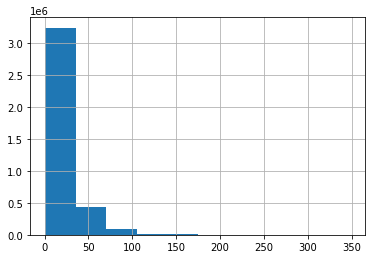

In [24]:
mosqutio_predictions.mosq_pred.hist()

In [13]:
# mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc, index = False)

mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

#dataset = timeline_file

In [14]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [15]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.936785,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,13.936785,13.936785,13.936785,13.936785,1
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.526527,NaN,NaN,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,24.463312,24.463312,24.463312,24.463312,1
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.321799,NaN,NaN,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,182.785111,182.785111,182.785111,182.785111,11
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012812,NaN,NaN,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,183.797923,183.797923,183.797923,183.797923,11
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.438097,NaN,NaN,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,189.236020,189.236020,189.236020,189.236020,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801727,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2023-12-27,2023,12,27,0.583661,0.404627,-0.422635,-0.404627,0.579778,0.389517,-0.427684,-0.389517,0.037344,0.039494,0.046348,0.039494,14269.000000,14127.000000,14261.451613,14267.928571,14448.741935,14448.741935,14011.838710,13970.000000,14101.870968,14101.870968,0.000000,14198.000000,14136.645161,14118.964286,14275.306452,14275.306452,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,5.312378,122.037563,208.626293,2635.919969,7
3801728,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2023-12-28,2023,12,28,0.583661,0.404627,-0.422635,-0.404627,0.579778,0.389517,-0.427684,-0.389517,0.037344,0.039494,0.046348,0.039494,14341.000000,14137.000000,14261.451613,14267.928571,14448.741935,14448.741935,14011.838710,13970.000000,14101.870968,14101.870968,0.000000,14239.000000,14136.645161,14118.964286,14275.306452,14275.306452,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,5.312378,122.037563,196.587694,2635.919969,8
3801729,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2023-12-29,2023,12,29,0.504655,0.375085,-0.385935,-0.375085,0.528328,0.380804,-0.404880,-0.380804,0.027753,0.037374,0.033740,0.037374,14304.000000,14137.000000,14261.451613,14267.928571,14448.741935,14448.741935,14011.838710,13970.000000,14101.870968,14101.870968,0.347183,14220.500000,14136.645161,14118.964286,14275.306452,14275.306452,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,0.617235,20.901368,194.917127,2636.267152,11
3801730,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2023-12-30,2023,12,30,0.504655,0.375085,-0.385935,-0.37508

In [16]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [17]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [18]:
dataset_locations

,x,y
0,21.190210,39.655160
1,21.190210,39.691090
2,21.236460,39.547360
3,21.236460,39.583290
4,21.236460,39.619230
...,...,...
689,23.254640,39.167380
690,23.254640,39.203310
691,23.254640,39.239250
692,23.254640,39.275180


In [19]:
dataset_locations_per_year

,x,y,year
0,21.190210,39.655160,2009
1,21.190210,39.655160,2010
2,21.190210,39.655160,2011
3,21.190210,39.655160,2012
4,21.190210,39.655160,2013
...,...,...,...
10405,23.300860,39.203310,2019
10406,23.300860,39.203310,2020
10407,23.300860,39.203310,2021
10408,23.300860,39.203310,2022


In [20]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [21]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 4.288279034553442e-06
Max distance: 0.00045796332980419137


In [22]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [23]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,station_id,x_string,y_string,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.190210,39.655160,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780
1,21.190210,39.691090,NaN,21.19021g,39.69109g,23160.169384,346.751574,12,89.441101,1312.022269,166.357352,0.000000,19.208773
2,21.236460,39.547360,NaN,21.23646g,39.54736g,29712.344392,1560.079774,33,301.668176,1642.246643,185.243714,0.000000,1.000000
3,21.236460,39.583290,NaN,21.23646g,39.58329g,28296.253996,73.899784,28,118.019612,1293.667865,180.709172,0.000000,36.806189
4,21.236460,39.619230,NaN,21.23646g,39.61923g,27371.455115,1028.557413,35,67.261475,1299.837739,133.863435,0.000000,1.017342
...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,23.254640,39.167380,NaN,23.25464g,39.16738g,2927.992588,6164.324626,20,150.944226,299.161539,186.676237,0.000000,1.092159
690,23.254640,39.203310,NaN,23.25464g,39.20331g,3538.764441,2412.291850,12,263.973650,298.414731,170.190030,0.000000,1.000000
691,23.254640,39.239250,NaN,23.25464g,39.23925g,4268.432276,2089.637888,2,136.716241,303.961164,175.337355,0.000000,2.880792
692,23.254640,39.275180,NaN,23.25464g,39.27518g,2388.893554,678.662812,25,120.826251,234.983542,171.762613,0.000000,7.010646


In [24]:
dataset_geo.dtypes

x                     float64
y                     float64
station_id            float64
x_string               object
y_string               object
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [25]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [26]:
dataset_geo.dtypes

x                     float64
y                     float64
station_id            float64
x_string               object
y_string               object
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [27]:
dataset_geo

,x,y,station_id,x_string,y_string,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.190210,39.655160,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780
1,21.190210,39.691090,NaN,21.19021g,39.69109g,23160.169384,346.751574,12,89.441101,1312.022269,166.357352,0.000000,19.208773
2,21.236460,39.547360,NaN,21.23646g,39.54736g,29712.344392,1560.079774,33,301.668176,1642.246643,185.243714,0.000000,1.000000
3,21.236460,39.583290,NaN,21.23646g,39.58329g,28296.253996,73.899784,28,118.019612,1293.667865,180.709172,0.000000,36.806189
4,21.236460,39.619230,NaN,21.23646g,39.61923g,27371.455115,1028.557413,35,67.261475,1299.837739,133.863435,0.000000,1.017342
...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,23.254640,39.167380,NaN,23.25464g,39.16738g,2927.992588,6164.324626,20,150.944226,299.161539,186.676237,0.000000,1.092159
690,23.254640,39.203310,NaN,23.25464g,39.20331g,3538.764441,2412.291850,12,263.973650,298.414731,170.190030,0.000000,1.000000
691,23.254640,39.239250,NaN,23.25464g,39.23925g,4268.432276,2089.637888,2,136.716241,303.961164,175.337355,0.000000,2.880792
692,23.254640,39.275180,NaN,23.25464g,39.27518g,2388.893554,678.662812,25,120.826251,234.983542,171.762613,0.000000,7.010646


In [28]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [29]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [30]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [31]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [32]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [33]:
landcover_2023 = landcover_2022

In [34]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.0
Max distance: 0.0
Year: 2010
Min distance: 0.0
Max distance: 0.0
Year: 2011
Min distance: 0.0
Max distance: 0.0


Year: 2012
Min distance: 0.0
Max distance: 0.0
Year: 2013
Min distance: 0.0
Max distance: 0.0
Year: 2014
Min distance: 0.0
Max distance: 0.0
Year: 2015
Min distance: 0.0
Max distance: 0.0
Year: 2016
Min distance: 0.0
Max distance: 0.0
Year: 2017
Min distance: 0.0
Max distance: 0.0
Year: 2018
Min distance: 0.0
Max distance: 0.0
Year: 2019
Min distance: 0.0
Max distance: 0.0
Year: 2020
Min distance: 0.0
Max distance: 0.0
Year: 2021
Min distance: 0.0
Max distance: 0.0
Year: 2022
Min distance: 0.0
Max distance: 0.0
Year: 2023
Min distance: 0.0
Max distance: 0.0


In [35]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [36]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.190210,39.655160,2009,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
1,21.190210,39.691090,2009,31,86,30,86.000000,30,86,10,10,1,6,6,2,0
2,21.236460,39.547360,2009,31,94,36,92.000000,30,94,12,12,1,6,7,2,0
3,21.236460,39.583290,2009,31,89,30,89.000000,30,89,10,10,1,6,6,2,0
4,21.236460,39.619230,2009,15,94,10,94.000000,10,94,5,5,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10405,23.254640,39.167380,2023,12,82,10,97.000000,10,97,2,2,5,2,2,2,0
10406,23.254640,39.203310,2023,11,90,10,90.000000,10,90,1,1,7,1,1,2,0
10407,23.254640,39.239250,2023,11,72,10,70.000000,10,70,1,1,7,1,1,2,0
10408,23.254640,39.275180,2023,21,80,20,80.000000,20,80,8,8,4,2,2,2,0


In [37]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [38]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [39]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [40]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,station_id,x_string,y_string,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.936785,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,13.936785,13.936785,13.936785,13.936785,1,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.526527,NaN,NaN,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,24.463312,24.463312,24.463312,24.463312,1,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.321799,NaN,NaN,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,182.785111,182.785111,182.785111,182.785111,11,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012812,NaN,NaN,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,183.797923,183.797923,183.797923,183.797923,11,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,NaN,13334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.438097,NaN,NaN,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,189.236020,189.236020,189.236020,189.236020,11,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801727,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2023-12-27,2023,12,27,0.583661,0.404627,-0.422635,-0.404627,0.579778,0.389517,-0.427684,-0.389517,0.037344,0.039494,0.046348,0.039494,14269.000000,14127.000000,14261.451613,14267.928571,14448.741935,14448.741935,14011.838710,13970.000000,14101.870968,14101.870968,0.000000,14198.000000,14136.645161,14118.964286,14275.306452,14275.306452,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,5.312378,122.037563,208.626293,2635.919969,7,NaN,23.30086g,39.20331g,2848.456012,1879

In [41]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [42]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [43]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [44]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [45]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [46]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,station_id,x_string,y_string,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.837780,39.583290,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13551.000000,12658.000000,13551.000000,NaN,NaN,NaN,12658.000000,NaN,NaN,NaN,1.868544,13328.000000,13328.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1.868544,1.868544,1.868544,1.868544,1,None,21.83778g,39.58329g,0.000000,10.738235,2,0.000000,85.575241,111.425738,0.000000,1.000000,31,98,36,99.000000,30,98,12,12,1,6,7,2,0
1,2009-01-01,EL61,θεσσαλια,EL612,λαρισα,22.302140,39.759360,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13853.000000,13519.000000,13853.000000,NaN,NaN,NaN,13519.000000,NaN,NaN,NaN,1.216936,13674.000000,13674.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1.216936,1.216936,1.216936,1.216936,1,None,22.30214g,39.75936g,807.833526,3.470693,2,48.757971,2.749400,139.798569,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
2,2009-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.792460,39.382980,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13592.000000,13580.000000,13592.000000,NaN,NaN,NaN,13580.000000,NaN,NaN,NaN,23.539793,13679.500000,13679.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,23.539793,23.539793,23.539793,23.539793,1,None,22.79246g,39.38298g,493.305640,59.481798,2,48.764328,17.278795,132.356349,0.000000,1.000000,31,99,20,99.000000,30,99,12,12,1,6,1,2,0
3,2009-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.837780,39.583290,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13551.000000,12658.000000,13551.000000,NaN,NaN,NaN,12658.000000,NaN,NaN,NaN,6.803264,13328.000000,13328.000000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,11.966679,11.966679,11.966679,11.966679,1,None,21.83778g,39.58329g,0.000000,10.738235,2,0.000000,85.575241,111.425738,0.000000,1.000000,31,98,36,99.000000,30,98,12,12,1,6,7,2,0
4,2009-01-02,EL61,θεσσαλια,EL612,λαρισα,22.302140,39.759360,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13853.000000,13519.000000,13853.000000,NaN,NaN,NaN,13519.000000,NaN,NaN,NaN,0.012513,13674.000000,13674.000000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1.229449,1.229449,1.229449,1.229449,1,None,22.30214g,39.75936g,807.833526,3.470693,2,48.757971,2.749400,139.798569,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16429,2023-12-30,EL61,θεσσαλια,EL612,λαρισα,22.302140,39.759360,2023,12,30,-0.337748,-0.159391,-0.566412,-0.726619,-0.165005,-0.166280,-0.533666,-0.611225,0.005139,0.011602,0.004516,0.011602,14219.000000,13693.000000,14122.483871,14265.178571,14375.806452,14375.806452,13798.387097,13652.964286,13883.193548,13883.193548,0.000000,13971.500000,13999.983871,13963.803571,13655.612903,13655.612903,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,0.01029

In [47]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,station_id,x_string,y_string,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.080230,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13317.000000,12658.000000,13317.000000,NaN,NaN,NaN,12658.000000,NaN,NaN,NaN,0.120210,13148.000000,13148.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.120210,0.120210,0.120210,0.120210,1,NaN,21.19021g,39.08023g,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,3,69,3,64.000000,3,69,1,0,0,0,0,1,0
1,2009-01-01,EL61,θεσσαλια,EL612,λαρισα,21.977880,39.184420,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13390.000000,12927.000000,13390.000000,NaN,NaN,NaN,12927.000000,NaN,NaN,NaN,0.389246,13372.500000,13372.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.389246,0.389246,0.389246,0.389246,1,NaN,21.97788g,39.18442g,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,11,67,9,67.000000,10,67,1,1,1,1,1,2,0
2,2009-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.561370,39.023650,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13460.000000,13521.000000,13460.000000,NaN,NaN,NaN,13521.000000,NaN,NaN,NaN,0.033392,13547.000000,13547.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.033392,0.033392,0.033392,0.033392,1,NaN,22.56137g,39.02365g,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,11,63,9,63.000000,10,63,1,1,1,1,1,2,0
3,2009-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.080230,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12897.000000,12658.000000,13251.500000,NaN,NaN,NaN,12658.000000,NaN,NaN,NaN,1.025448,13148.000000,13148.000000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,3.257632,3.257632,3.257632,3.257632,1,NaN,21.19021g,39.08023g,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,3,69,3,64.000000,3,69,1,0,0,0,0,1,0
4,2009-01-02,EL61,θεσσαλια,EL612,λαρισα,21.977880,39.184420,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13039.000000,12927.000000,13306.000000,NaN,NaN,NaN,12927.000000,NaN,NaN,NaN,0.005928,13372.500000,13372.500000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1.229449,1.229449,1.229449,1.229449,1,NaN,21.97788g,39.18442g,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,11,67,9,67.000000,10,67,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16429,2023-12-30,EL61,θεσσαλια,EL612,λαρισα,21.977880,39.184420,2023,12,30,-0.337748,-0.159391,-0.566412,-0.726619,-0.165005,-0.166280,-0.533666,-0.611225,0.005139,0.011602,0.004516,0.011602,13932.000000,13575.000000,13582.129032,13472.678571,13862.612903,13862.612903,13326.516129,13229.857143,13448.612903,13448.612903,0.000000,13815.500000,13454.322581,13351.267857,13655.612903,13655.612903,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,0.000000

In [49]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean','lst_night','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_nuts3_mean[['rainfall','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan', 'mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [50]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2009-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13662.993243,13662.993243,NaN,NaN,NaN,13037.235294,13037.235294,NaN,NaN,NaN,13338.312500,13338.312500,NaN,NaN,NaN,8.394627,8.394627,8.394627,8.394627,8.394627,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2
1,2009-01-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13766.345725,13766.345725,NaN,NaN,NaN,13450.575758,13450.575758,NaN,NaN,NaN,13635.132979,13635.132979,NaN,NaN,NaN,5.020138,5.020138,5.020138,5.020138,5.020138,1.000000,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2
2,2009-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13770.628866,13770.628866,NaN,NaN,NaN,13625.952381,13625.952381,NaN,NaN,NaN,13721.579365,13721.579365,NaN,NaN,NaN,4.725215,4.725215,4.725215,4.725215,4.725215,1.000000,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2
3,2009-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13659.027027,13661.010135,NaN,NaN,NaN,13037.235294,13037.235294,NaN,NaN,NaN,13338.312500,13338.312500,NaN,NaN,NaN,9.530763,17.925390,17.925390,17.925390,17.925390,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2
4,2009-01-02,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13761.821561,13764.083643,NaN,NaN,NaN,13450.710280,13453.042056,NaN,NaN,NaN,13626.673267,13628.193069,NaN

<AxesSubplot:>

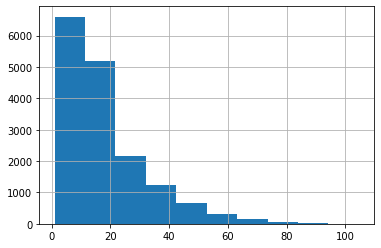

In [51]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [52]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

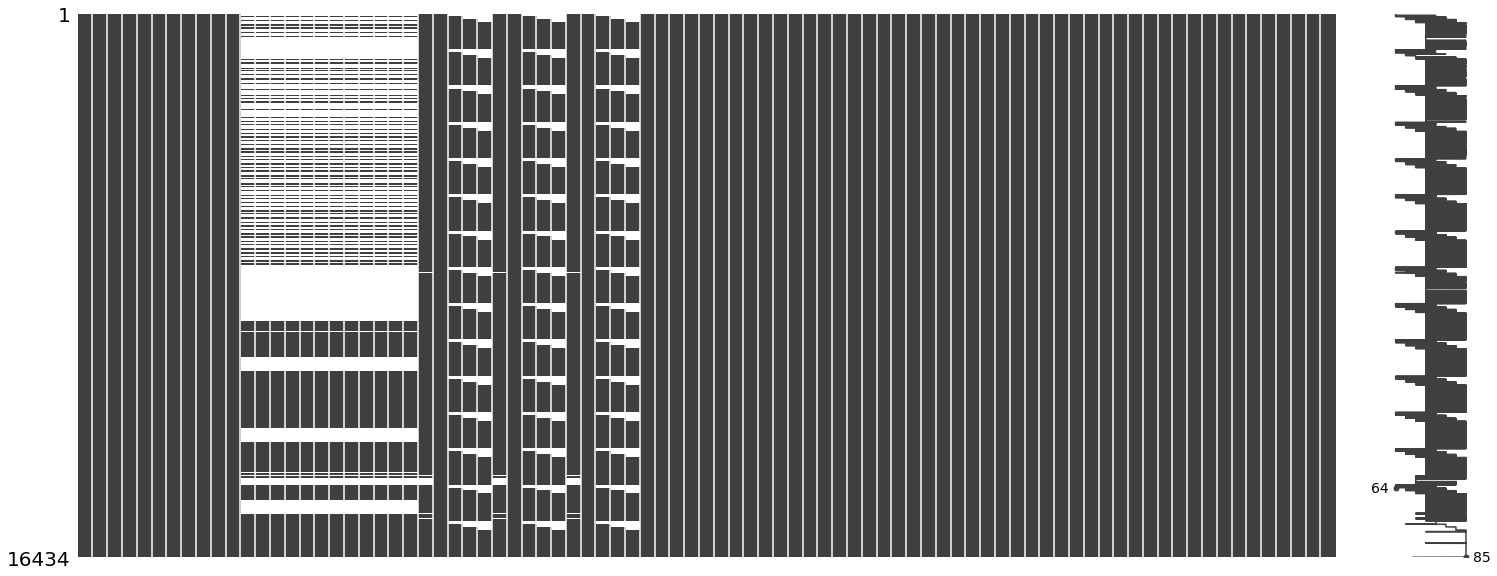

In [53]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [54]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [55]:
bio_values_df = pd.DataFrame(bio_values)

In [56]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,"καρδιτσα, τρικαλα",2009,1,-12.405294,11.129308,406.678840
1,"καρδιτσα, τρικαλα",2009,2,-3.714780,12.352013,139.530155
2,"καρδιτσα, τρικαλα",2009,3,-0.913849,17.622579,233.229852
3,"καρδιτσα, τρικαλα",2009,4,3.172461,22.840629,99.199859
4,"καρδιτσα, τρικαλα",2009,5,7.262658,34.039748,67.843200
...,...,...,...,...,...,...
535,"μαγνησια, σποραδες",2023,8,19.252062,38.866495,8.800347
536,"μαγνησια, σποραδες",2023,9,15.099072,31.923814,1319.551884
537,"μαγνησια, σποραδες",2023,10,12.553918,24.313299,44.317612
538,"μαγνησια, σποραδες",2023,11,2.212062,22.239897,162.589470


In [57]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [58]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.109865,0.109865,NaN,NaN,NaN,-12.405294,-12.405294,NaN,NaN,NaN,-6.147715,-6.383750,NaN,NaN,NaN,8.394627,8.394627,8.394627,8.394627,8.394627,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840
1,2009-01-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.176914,2.176914,NaN,NaN,NaN,-4.138485,-4.138485,NaN,NaN,NaN,-0.980785,-0.447340,NaN,NaN,NaN,5.020138,5.020138,5.020138,5.020138,5.020138,1.000000,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365
2,2009-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.262577,2.262577,NaN,NaN,NaN,-0.630952,-0.630952,NaN,NaN,NaN,0.815812,1.281587,NaN,NaN,NaN,4.725215,4.725215,4.725215,4.725215,4.725215,1.000000,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067
3,2009-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.030541,0.070203,NaN,NaN,NaN,-12.405294,-12.405294,NaN,NaN,NaN,-6.187377,-6.383750,NaN,NaN,NaN,9.530763,17.925390,17.925390,17.925390,17.925390,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840
4,2009-01-02,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.086431

<AxesSubplot:>

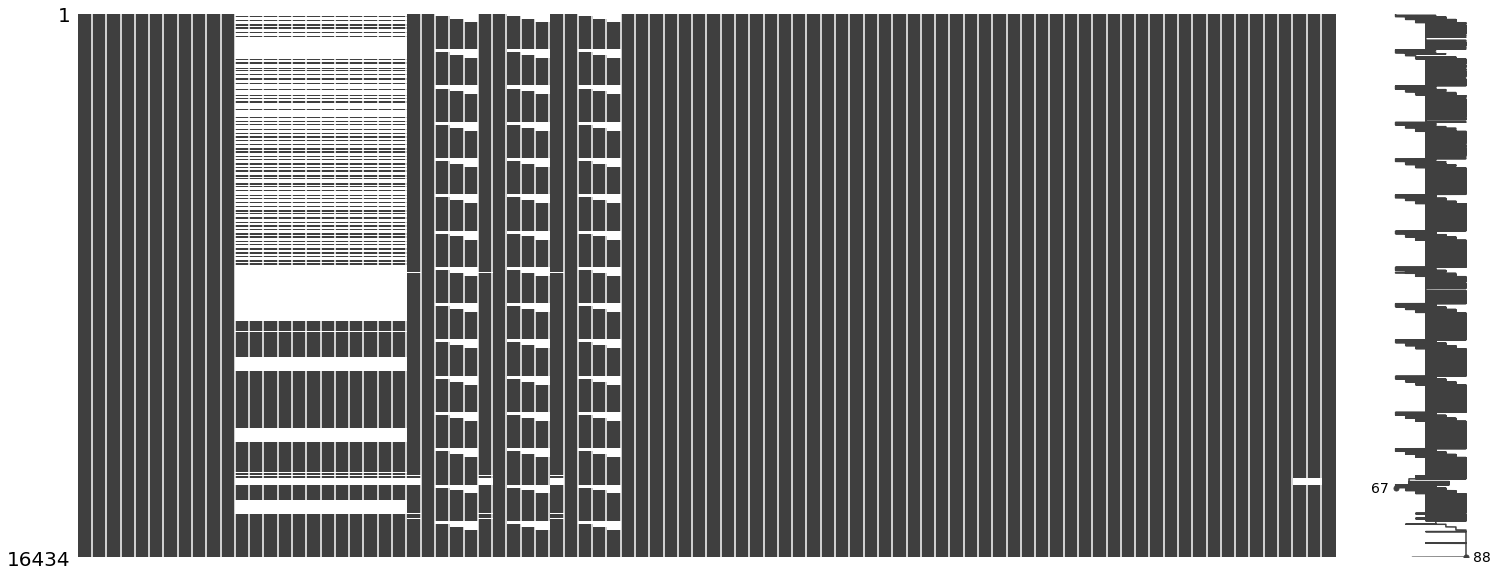

In [59]:
missingno.matrix(dataset)

In [60]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [61]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [62]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2009-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.109865,0.109865,NaN,NaN,NaN,-12.405294,-12.405294,NaN,NaN,NaN,-6.147715,-6.383750,NaN,NaN,NaN,8.394627,8.394627,8.394627,8.394627,8.394627,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,2009-01
1,2009-01-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.176914,2.176914,NaN,NaN,NaN,-4.138485,-4.138485,NaN,NaN,NaN,-0.980785,-0.447340,NaN,NaN,NaN,5.020138,5.020138,5.020138,5.020138,5.020138,1.000000,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365,2009-01
2,2009-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.262577,2.262577,NaN,NaN,NaN,-0.630952,-0.630952,NaN,NaN,NaN,0.815812,1.281587,NaN,NaN,NaN,4.725215,4.725215,4.725215,4.725215,4.725215,1.000000,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067,2009-01
3,2009-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.030541,0.070203,NaN,NaN,NaN,-12.405294,-12.405294,NaN,NaN,NaN,-6.187377,-6.383750,NaN,NaN,NaN,9.530763,17.925390,17.925390,17.925390,17.925390,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,2009-01
4,2009-01-02,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,2,1,2009,1,NaN,N

In [63]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2009,2,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,-0.029865,-0.007393,NaN,NaN,NaN,-12.405294,-12.405294,NaN,NaN,NaN,-4.546959,-6.383750,NaN,NaN,NaN,0.262757,8.394627,8.394627,8.394627,8.394627,1.000000,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840
1,1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.060781,2.088364,NaN,NaN,NaN,4.001541,-4.316667,NaN,NaN,NaN,7.062975,-0.831304,NaN,NaN,NaN,0.002330,5.020138,5.020138,5.020138,5.020138,1.000000,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365
2,2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.262577,2.262577,NaN,NaN,NaN,-1.439254,-0.630952,NaN,NaN,NaN,0.815812,1.281587,NaN,NaN,NaN,0.039290,4.725215,4.725215,4.725215,4.725215,1.000000,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067
3,3,2009-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2,2009,6,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,5.625849,4.699393,8.259905,NaN,NaN,-3.536855,1.761039,2.866226,NaN,NaN,1.044497,3.230216,5.577571,NaN,NaN,0.003050,1.603510,18.525352,155.148509,413.701339,2.786164,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-3.714780,12.352013,13

In [64]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [65]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,4.699393,NaN,NaN,NaN,1.761039,NaN,NaN,NaN,3.230216,NaN,NaN,NaN,13.118672,73.665845,137.085867,398.284212,406.678840,159.569182,5.147393,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,6.793895,NaN,NaN,NaN,1.699212,NaN,NaN,NaN,4.246554,NaN,NaN,NaN,7.838270,45.404332,92.588013,237.966227,242.986365,61.584229,1.986588,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365
2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.264925,1.897135,4.081030,6.264925,NaN,NaN,NaN,2.651805,NaN,NaN,NaN,4.458365,NaN,NaN,NaN,8.009196,48.291400,89.714789,243.559852,248.285067,45.061856,1.453608,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067
3,2009-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,2009,0.205035,0.367739,0.233671,-0.367739,0.187385,0.341510,0.220182,-0.341510,0.041014,0.045679,0.065527,0.045679,7.547264,0.200398,3.873831,4.699393,7.541364,NaN,NaN,1.761039,0.200398,NaN,NaN,3.230216,3.870881,NaN,NaN,4.983220,3.697190,18.525352,155.148509,546.208995,175.371069,6.263252,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.6

In [66]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


In [67]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            540 non-null    period[M]
 1   NUTS2_ID                540 non-null    object   
 2   NUTS2_NAME              540 non-null    object   
 3   NUTS3_ID                540 non-null    object   
 4   NUTS3_NAME              540 non-null    object   
 5   x                       540 non-null    float64  
 6   y                       540 non-null    float64  
 7   month                   540 non-null    int64    
 8   year                    540 non-null    int64    
 9   ndvi                    531 non-null    float64  
 10  ndmi                    531 non-null    float64  
 11  ndwi                    531 non-null    float64  
 12  ndbi                    531 non-null    float64  
 13  ndvi_mean               531 non-null    float64  
 14  ndmi_mean 

In [68]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    84 non-null     object
 1   NUTS3_NAME    84 non-null     object
 2   dt_placement  84 non-null     object
 3   cases         84 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 2.8+ KB


In [69]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [70]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3
5,θεσσαλια,"καρδιτσα, τρικαλα",2011-08,8
6,θεσσαλια,"καρδιτσα, τρικαλα",2011-09,3
7,θεσσαλια,"καρδιτσα, τρικαλα",2011-10,0
8,θεσσαλια,"καρδιτσα, τρικαλα",2018-07,0
9,θεσσαλια,"καρδιτσα, τρικαλα",2018-08,0


In [71]:
wnv_file['cases'].value_counts()

0     48
1      7
3      6
2      5
4      3
7      3
8      2
5      2
6      2
22     1
11     1
15     1
19     1
23     1
14     1
Name: cases, dtype: int64

In [72]:
wnv_file.cases.sum()

210

In [73]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [74]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,4.699393,NaN,NaN,NaN,1.761039,NaN,NaN,NaN,3.230216,NaN,NaN,NaN,13.118672,73.665845,137.085867,398.284212,406.678840,159.569182,5.147393,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,NaN
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,6.793895,NaN,NaN,NaN,1.699212,NaN,NaN,NaN,4.246554,NaN,NaN,NaN,7.838270,45.404332,92.588013,237.966227,242.986365,61.584229,1.986588,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365,NaN
2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.264925,1.897135,4.081030,6.264925,NaN,NaN,NaN,2.651805,NaN,NaN,NaN,4.458365,NaN,NaN,NaN,8.009196,48.291400,89.714789,243.559852,248.285067,45.061856,1.453608,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067,NaN
3,2009-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,2009,0.205035,0.367739,0.233671,-0.367739,0.187385,0.341510,0.220182,-0.341510,0.041014,0.045679,0.065527,0.045679,7.547264,0.200398,3.873831,4.699393,7.541364,NaN,NaN,1.761039,0.200398,NaN,NaN,3.230216,3.870881,NaN,NaN,4.983220,3.697190,18.525352,155.148509,546.208995,175.371069,6.263252,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.4643

In [75]:
merged = fillna(merged,{'cases': 0})

In [76]:
merged['cases'].value_counts()

0.000000     504
1.000000       7
3.000000       6
2.000000       5
4.000000       3
7.000000       3
5.000000       2
8.000000       2
6.000000       2
15.000000      1
19.000000      1
23.000000      1
22.000000      1
14.000000      1
11.000000      1
Name: cases, dtype: int64

In [77]:
merged.cases.sum()

210.0

In [78]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

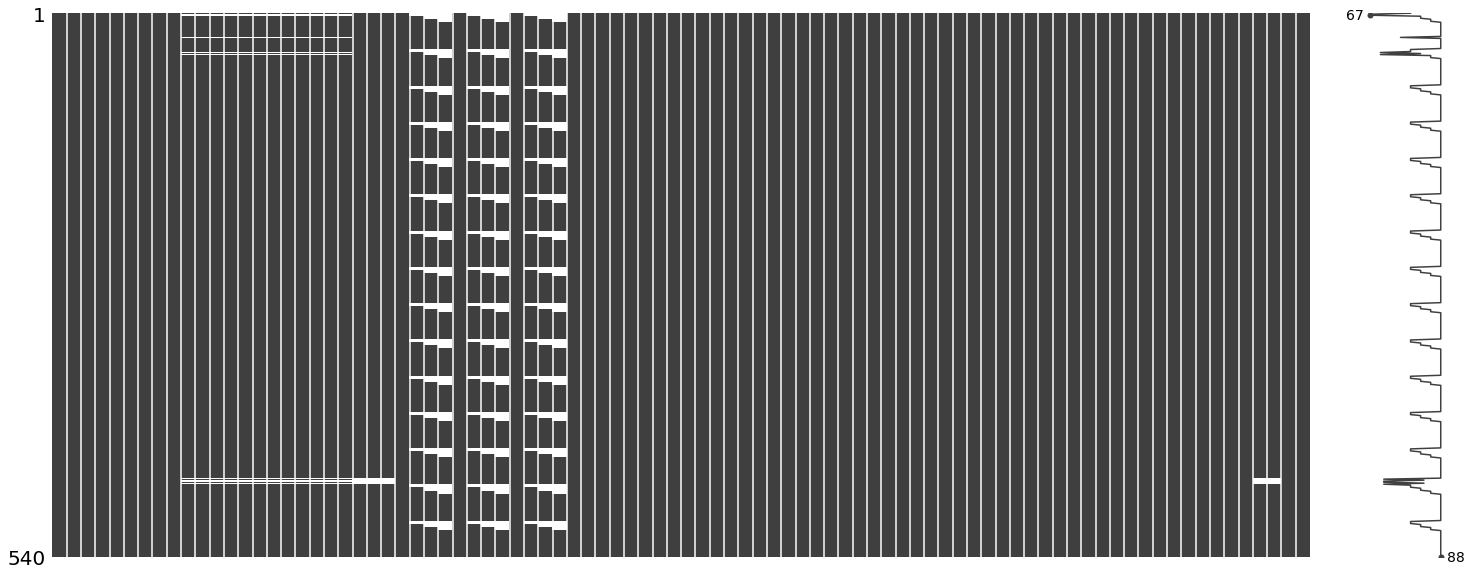

In [79]:
missingno.matrix(merged)

In [80]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

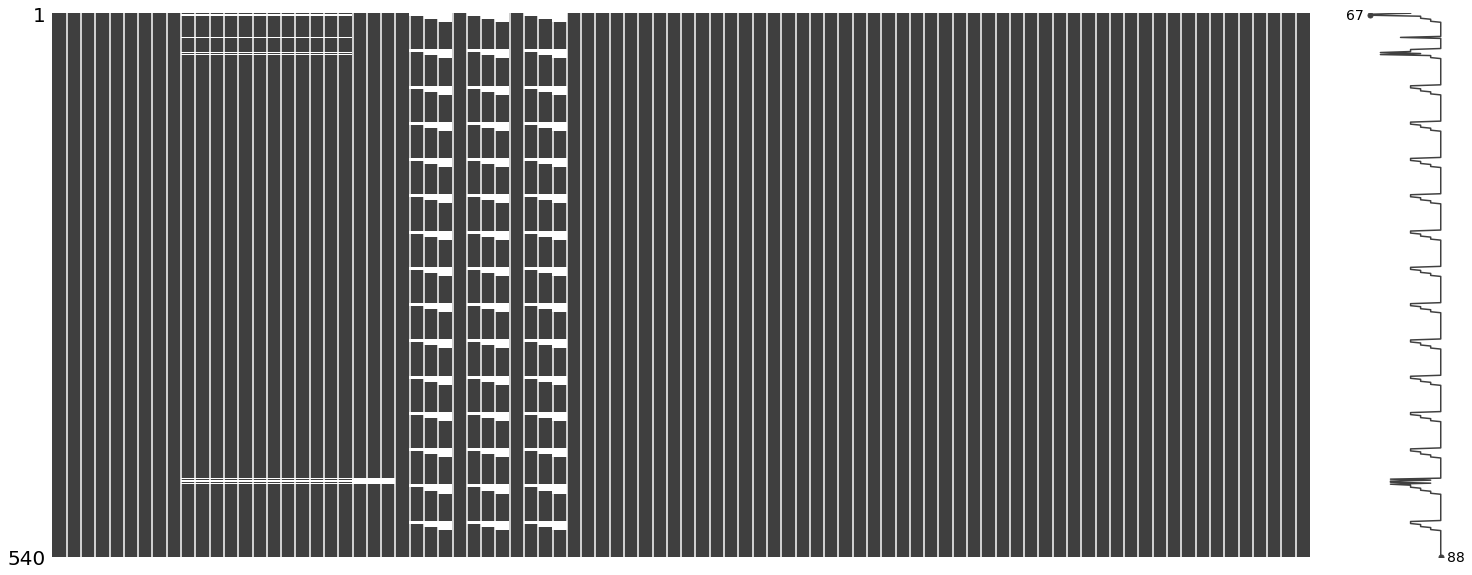

In [81]:
missingno.matrix(merged)

In [82]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023], dtype=int64)

In [83]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['καρδιτσα, τρικαλα', 'λαρισα', 'μαγνησια, σποραδες'], dtype=object)

In [84]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [85]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"καρδιτσα, τρικαλα",2009,14.958333,20.083333,37.893082,917.372318,41.000000,-12.000000,53.000000,5.666667,25.166667,25.833333,3.833333,2052.000000,406.000000,45.000000,69.435433,971.000000,166.000000,200.000000,839.000000
1,λαρισα,2009,17.250000,22.166667,45.238095,931.640781,45.000000,-4.000000,49.000000,8.333333,28.833333,28.833333,6.333333,1448.000000,281.000000,37.000000,67.310943,640.000000,170.000000,170.000000,594.000000
2,"μαγνησια, σποραδες",2009,16.833333,19.500000,44.318182,847.277279,42.000000,-2.000000,44.000000,9.000000,27.500000,27.500000,7.166667,1428.000000,305.000000,22.000000,74.352423,644.000000,122.000000,122.000000,473.000000
3,"καρδιτσα, τρικαλα",2010,15.250000,19.000000,46.341463,806.930210,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,5.500000,2017.000000,351.000000,9.000000,63.035181,821.000000,143.000000,143.000000,705.000000
4,λαρισα,2010,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1367.000000,275.000000,22.000000,62.742437,548.000000,158.000000,158.000000,377.000000
5,"μαγνησια, σποραδες",2010,17.291667,19.250000,46.951220,812.532051,40.000000,-1.000000,41.000000,16.833333,27.833333,27.833333,7.833333,1255.000000,270.000000,11.000000,67.876691,484.000000,132.000000,132.000000,391.000000
6,"καρδιτσα, τρικαλα",2011,14.083333,19.500000,50.000000,843.378847,35.000000,-4.000000,39.000000,4.000000,24.500000,24.500000,4.000000,1227.000000,214.000000,2.000000,63.668711,475.000000,91.000000,91.000000,475.000000
7,λαρισα,2011,15.916667,22.500000,48.913043,906.249347,42.000000,-4.000000,46.000000,10.166667,27.333333,27.333333,5.666667,928.000000,123.000000,4.000000,50.136650,314.000000,136.000000,136.000000,284.000000
8,"μαγνησια, σποραδες",2011,15.583333,18.666667,46.666667,842.839717,38.000000,-2.000000,40.000000,7.000000,26.166667,26.166667,6.000000,1083.000000,180.000000,1.000000,59.822377,449.000000,124.000000,124.000000,381.000000
9,"καρδιτσα, τρικαλα",2012,15.500000,20.666667,43.055556,937.598480,40.000000,-8.000000,48.000000,11.500000,26.333333,26.333333,3.333333,1800.000000,344.000000,9.000000,69.790825,805.000000,52.000000,52.000000,680.000000


In [86]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [87]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'λαρισα')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
37,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2010,0.171080,0.073819,-0.029729,-0.073819,0.168783,0.129570,0.029590,-0.129570,0.036226,0.032176,0.046706,0.032176,10.166321,1.955046,6.060683,10.166321,NaN,NaN,NaN,1.955046,NaN,NaN,NaN,6.060683,NaN,NaN,NaN,3.027128,36.493844,58.395719,92.799772,93.840961,31.082437,1.002659,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-0.746272,15.841613,93.840961,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1367.000000,275.000000,22.000000,62.742437,548.000000,158.000000,158.000000,377.000000
40,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,2,2010,0.335722,0.353695,0.075658,-0.353695,0.323092,0.322652,0.047494,-0.322652,0.042533,0.061832,0.085925,0.061832,11.081015,2.682352,6.881683,10.166321,11.080809,NaN,NaN,1.955046,2.673213,NaN,NaN,6.060683,6.877011,NaN,NaN,7.365524,57.538984,92.239639,213.903129,300.075647,115.060932,4.109319,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.924420,15.088566,206.234685,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1367.000000,275.000000,22.000000,62.742437,548.000000,158.000000,158.000000,377.000000
43,2010-03,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,3,2010,0.453533,0.191539,-0.234794,-0.191539,0.452084,0.189661,-0.236358,-0.189661,0.068587,0.081192,0.053057,0.081192,18.182616,5.028989,11.605803,10.166321,11.080809,18.182616,NaN,1.955046,2.673213,5.028989,NaN,6.060683,6.877011,11.605803,NaN,3.838432,2.074941,45.860896,111.162258,419.067041,392.612903,12.664932,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,1.345341,23.178746,118.991394,0,17.291667,21.5833

In [88]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [89]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [90]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [92]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

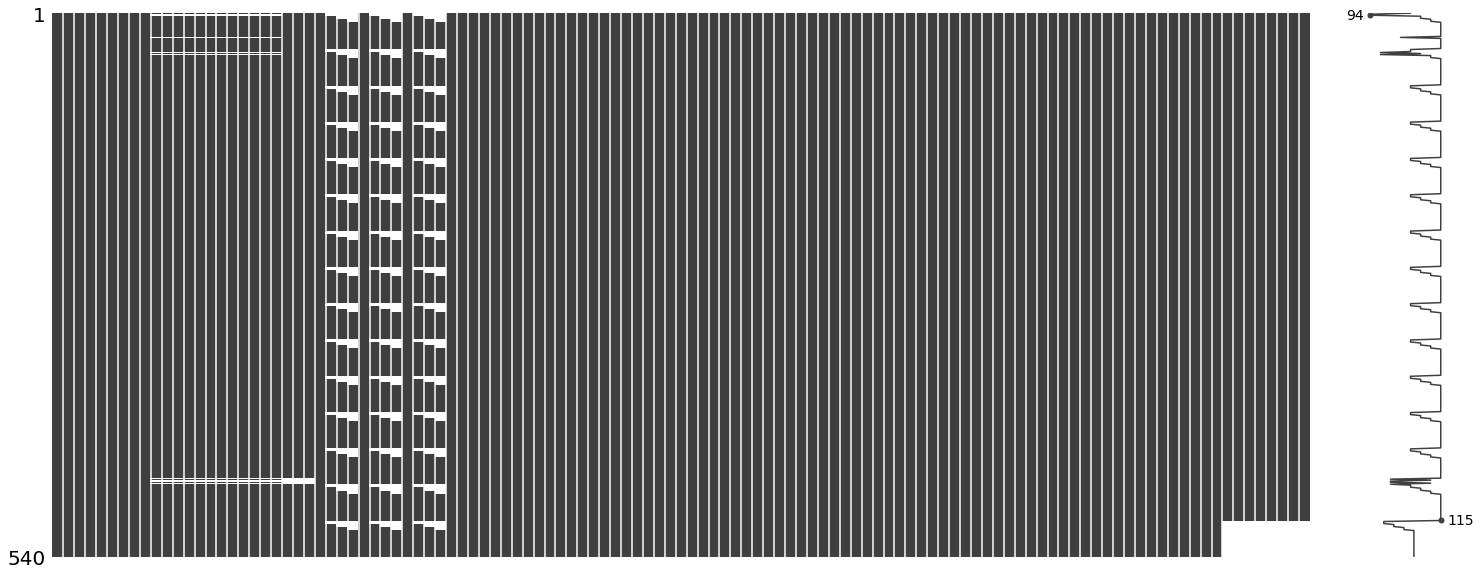

In [93]:
missingno.matrix(dataset)

In [94]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [95]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [96]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [98]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

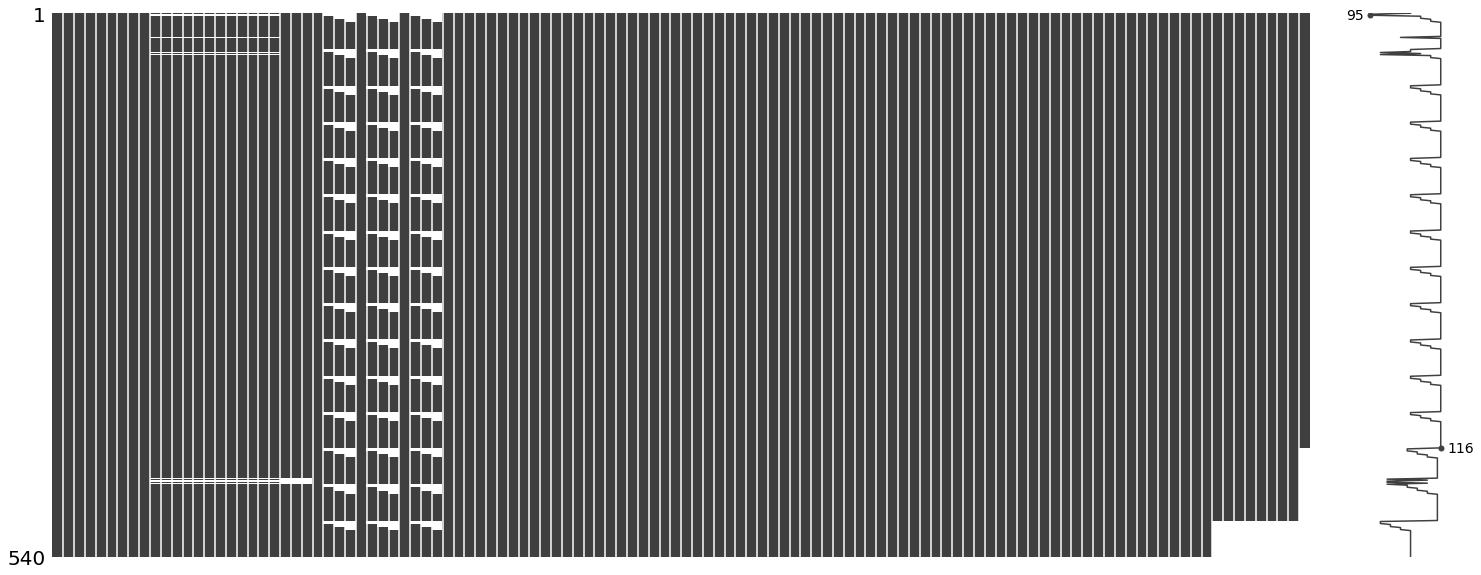

In [99]:
missingno.matrix(dataset)

In [100]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [101]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [102]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [103]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [104]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

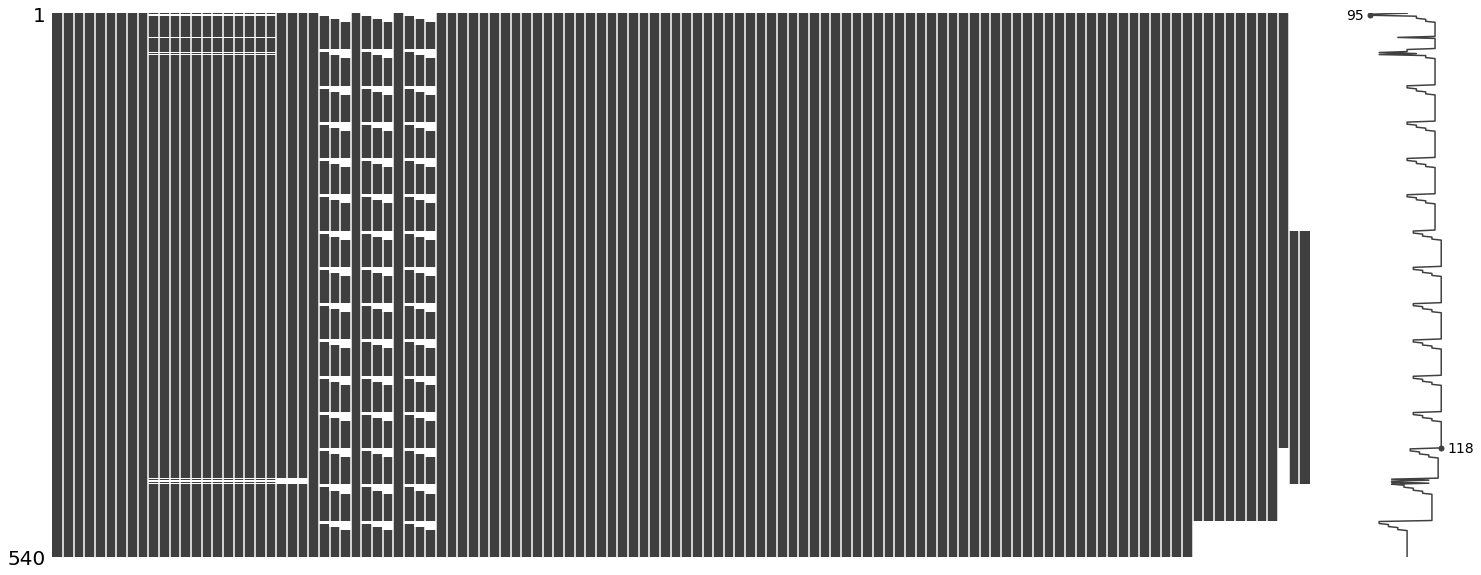

In [105]:
missingno.matrix(dataset)

In [106]:
missing = describe_dataframe(dataset)

In [107]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,6.666700
114,F_TOTAL,6.666700
115,MIO_EUR,20.000000
116,L_TOTAL,53.333300


In [108]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,4.699393,NaN,NaN,NaN,1.761039,NaN,NaN,NaN,3.230216,NaN,NaN,NaN,13.118672,73.665845,137.085867,398.284212,406.678840,159.569182,5.147393,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,0,14.958333,20.083333,37.893082,917.372318,41.000000,-12.000000,53.000000,5.666667,25.166667,25.833333,3.833333,2052.000000,406.000000,45.000000,69.435433,971.000000,166.000000,200.000000,839.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,6.793895,NaN,NaN,NaN,1.699212,NaN,NaN,NaN,4.246554,NaN,NaN,NaN,7.838270,45.404332,92.588013,237.966227,242.986365,61.584229,1.986588,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365,0,17.250000,22.166667,45.238095,931.640781,45.000000,-4.000000,49.000000,8.333333,28.833333,28.833333,6.333333,1448.000000,281.000000,37.000000,67.310943,640.000000,170.000000,170.000000,594.000000,23291.000000,94577.000000,25594.000000,143462.000000,22117.000000,93495.000000,30638.000000,146250.000000,5066.810000,NaN,NaN
2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.264925,1.897135,4.081030,6.264925,NaN,NaN,NaN,2.651805,NaN,NaN,NaN,4.458365,NaN,NaN,NaN,8.009196,48.291400,89.714789,243.559852,248.285067,45.061856,1.453608,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.60

In [109]:
dataset.reset_index(inplace=True, drop=True)

In [110]:
dataset['cases'].value_counts()

0     504
1       7
3       6
2       5
4       3
7       3
5       2
8       2
6       2
15      1
19      1
23      1
22      1
14      1
11      1
Name: cases, dtype: int64

In [111]:
dataset['cases'].sum()

210

In [112]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,4.699393,NaN,NaN,NaN,1.761039,NaN,NaN,NaN,3.230216,NaN,NaN,NaN,13.118672,73.665845,137.085867,398.284212,406.678840,159.569182,5.147393,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,0,14.958333,20.083333,37.893082,917.372318,41.000000,-12.000000,53.000000,5.666667,25.166667,25.833333,3.833333,2052.000000,406.000000,45.000000,69.435433,971.000000,166.000000,200.000000,839.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,6.793895,NaN,NaN,NaN,1.699212,NaN,NaN,NaN,4.246554,NaN,NaN,NaN,7.838270,45.404332,92.588013,237.966227,242.986365,61.584229,1.986588,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365,0,17.250000,22.166667,45.238095,931.640781,45.000000,-4.000000,49.000000,8.333333,28.833333,28.833333,6.333333,1448.000000,281.000000,37.000000,67.310943,640.000000,170.000000,170.000000,594.000000,23291.000000,94577.000000,25594.000000,143462.000000,22117.000000,93495.000000,30638.000000,146250.000000,5066.810000,NaN,NaN
2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.264925,1.897135,4.081030,6.264925,NaN,NaN,NaN,2.651805,NaN,NaN,NaN,4.458365,NaN,NaN,NaN,8.009196,48.291400,89.714789,243.559852,248.285067,45.061856,1.453608,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.60

In [113]:
cols = dataset.columns

In [114]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [115]:
len(cols)

118

In [116]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc, index = False)
